## TESTING MARGINALS
## Spike-and-slab regression

As the sticky Boomerang is specified for models that are sparse, in particular models with spike-and-slab priors, we choose to first consider the marginals of a spike-and-slab linear regression model. Let 
$$
y = \mathbf{X}\theta + \varepsilon
$$
such that $X^{\top}X=nI$ and let 
$$
\theta_j \mid \gamma_j \sim \gamma_j\mathcal{N}(0, \tau^2) + (1-\gamma_j)\delta_0
$$
where $\gamma_j$ is the prior inclusion probability $\mathbb{P}(\theta_i \neq 0)=\gamma_j$. Define the parameter 
$$
\kappa_i = \frac{\gamma_j}{1-\gamma_j}\pi_i(0) = \frac{\gamma_j}{1-\gamma_j}\frac{1}{\sqrt{2\pi \tau^2}}
$$
and the posterior
$$
\pi(\theta_j \mid y) = \tilde{\gamma_j}\mathcal{N}(\theta_j\mid m_j, s_j^2) + (1-\tilde{\gamma_j})\delta_0
$$
with slab parameters
$$
m_j = s_j^2\frac{n}{\sigma^2}\hat{z}_j \qquad s_j^2 = \left(\frac{n}{\sigma^2} + \frac{1}{\tau^2} \right)^{-1}
$$
where $\hat{z}_j=\frac{1}{n}\mathbf{X}^{\top}y$ is the OLS, such that
$$
\frac{\tilde{\gamma_j}}{(1-\tilde{\gamma_j})} = \frac{\gamma_j}{(1-\gamma_j)}\frac{\mathcal{N}(\hat{z}_j\mid, \tau^2+\sigma^2/n)}{\mathcal{N}(\hat{z}_j\mid, \sigma^2/n)}
$$

In [1]:
import autograd.numpy as anp
from autograd import grad
import numpy as np
from scipy.stats import norm

# ============================================================
# Data generation
# ============================================================
def generate_spike_slab_data(n=200, d=20, d_nonzero=5, sigma=1.0, tau=2.0, seed=42):
    rng = np.random.default_rng(seed)

    # Orthogonal design: X such that X^T X = nI
    # Take first d columns of a random orthogonal matrix, scaled by sqrt(n)
    Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
    X = Q[:, :d] * np.sqrt(n)

    # True theta: first d_nonzero are nonzero
    theta_true = np.zeros(d)
    theta_true[:d_nonzero] = rng.normal(loc=0, scale=tau, size=d_nonzero)

    # Observations
    y = X @ theta_true + rng.normal(scale=sigma, size=n)

    # OLS estimates
    z_hat = X.T @ y / n

    return X, y, theta_true, z_hat

# ============================================================
# Target and gradient
# ============================================================
def nll_spike_slab(z_hat, n, sigma, tau):
    """
    Energy for the continuous (slab) part of the posterior.
    E(theta) = sum_j  n/(2*sigma^2) * (z_hat_j - theta_j)^2 + 1/(2*tau^2) * theta_j^2
    """
    eta_lik = n / sigma**2
    eta_prior = 1.0 / tau**2

    def E(theta):
        return anp.sum(
            0.5 * eta_lik * (z_hat - theta)**2
            + 0.5 * eta_prior * theta**2
        )

    return E


def grad_spike_slab(z_hat, n, sigma, tau):
    """
    Gradient: nabla_j E = (n/sigma^2 + 1/tau^2) * theta_j - (n/sigma^2) * z_hat_j
    """
    eta_lik = n / sigma**2
    eta_prior = 1.0 / tau**2

    def gradE(theta):
        return (eta_lik + eta_prior) * theta - eta_lik * z_hat

    return gradE

# ============================================================
# Posterior quantities (closed form)
# ============================================================
def posterior_spike_slab_params(z_hat, n, sigma, tau, gamma_prior):
    """
    Returns posterior inclusion probabilities and slab parameters.
    """
    d = len(z_hat)
    eta_lik = n / sigma**2
    eta_prior = 1.0 / tau**2

    # Slab posterior parameters
    s2 = 1.0 / (eta_lik + eta_prior)
    m = s2 * eta_lik * z_hat

    # Posterior inclusion: gamma_post / (1 - gamma_post)
    #   = gamma / (1 - gamma) * N(z_hat; 0, tau^2 + sigma^2/n) / N(z_hat; 0, sigma^2/n)
    var_slab = tau**2 + sigma**2 / n
    var_spike = sigma**2 / n

    log_bf = (norm.logpdf(z_hat, 0, np.sqrt(var_slab))
              - norm.logpdf(z_hat, 0, np.sqrt(var_spike)))

    log_prior_odds = np.log(gamma_prior / (1 - gamma_prior))
    log_post_odds = log_prior_odds + log_bf

    gamma_post = 1.0 / (1.0 + np.exp(-log_post_odds))

    return m, s2, gamma_post

# ============================================================
# Analytical marginal density
# ============================================================
def marginal_pdf_spike_slab(theta_grid, m_j, s2_j, gamma_post_j):
    """
    Marginal posterior density for coordinate j.
    Continuous part: gamma_post * N(theta | m_j, s2_j)
    Point mass: (1 - gamma_post) * delta_0
    
    For histogram comparison, we only plot the continuous part,
    and separately check the fraction of samples at exactly zero.
    """
    return gamma_post_j * norm.pdf(theta_grid, m_j, np.sqrt(s2_j))

# ============================================================
# Setup
# ============================================================
n, d, d_nonzero = 200, 20, 5
sigma = 1.0
tau = 2.0
gamma_prior = 0.5  # prior inclusion probability

X, y, theta_true, z_hat = generate_spike_slab_data(
    n=n, d=d, d_nonzero=d_nonzero, sigma=sigma, tau=tau
)

# Target and gradient
E_ss = nll_spike_slab(z_hat, n, sigma, tau)
gradE_ss = grad_spike_slab(z_hat, n, sigma, tau)

# Posterior quantities
m, s2, gamma_post = posterior_spike_slab_params(z_hat, n, sigma, tau, gamma_prior)

# Kappa (prior value, fixed)
kappa = (gamma_prior / (1 - gamma_prior)) / np.sqrt(2 * np.pi * tau**2)

print("True theta:", theta_true)
print("OLS estimates:", z_hat)
print("Posterior means (slab):", m)
print("Posterior s^2:", s2)
print("Posterior inclusion prob:", gamma_post)
print("Kappa (prior, fixed):", kappa)
    

True theta: [-1.79953635 -2.51634498  0.66523259  0.30668657 -4.4491176   0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
OLS estimates: [-1.81612900e+00 -2.52963171e+00  5.45088077e-01  3.38011676e-01
 -4.37651041e+00 -3.48814253e-03 -2.66871747e-02 -3.83145312e-02
 -5.22418489e-02  6.01246591e-02 -3.43427705e-03  1.30006648e-01
  3.57314492e-02  7.93154321e-02 -1.06574775e-01  4.79985778e-02
  2.63742417e-03 -1.28584646e-01  1.69709958e-01 -6.48707373e-03]
Posterior means (slab): [-1.81386167e+00 -2.52647362e+00  5.44407567e-01  3.37589689e-01
 -4.37104660e+00 -3.48378780e-03 -2.66538574e-02 -3.82666979e-02
 -5.21766281e-02  6.00495971e-02 -3.42998956e-03  1.29844342e-01
  3.56868406e-02  7.92164116e-02 -1.06441722e-01  4.79386545e-02
  2.63413151e-03 -1.28424116e-01  1.69498085e-01 -6.47897502e-03]
Posterior s^2: 0.004993757802746567
Posterior inclusion prob: [1.         1.

In [2]:
import os
os.chdir('..')
os.getcwd()
from sazz.samplers.boomerang_sampler.StickyBoomerangSampler import StickyBoomerangSampler

N=10000

sampler = StickyBoomerangSampler(
    E=E_ss, N=N, D=d,
    grad_target=gradE_ss, kappa=kappa,
)
sampler.preprocess(method="diagonal")

In [3]:
sampler.sample_auto()

Sticky Boomerang time: 100%|█████████▉| 9999/10000 [00:05<00:00, 1686.27iter/s, time=7517.076]

Time passed: 7517.076119456119


In [5]:
from sazz.samplers.boomerang_sampler.utils import resample_sticky_pdmp_path
t, x = resample_sticky_pdmp_path(sampler, n_samples=4000)

In [4]:
# ============================================================
# Plotting: compare sampler output to analytical marginals
# ============================================================
def plot_spike_slab_marginal(samples_j, m_j, s2_j, gamma_post_j, title="", bins=200):
    """
    Compare sampler histogram to analytical marginal.
    - Continuous part: histogram of nonzero samples vs gamma_post * N(m_j, s2_j)
    - Spike part: fraction of exactly-zero samples vs (1 - gamma_post)
    """
    import matplotlib.pyplot as plt

    at_zero = np.sum(samples_j == 0.0) / len(samples_j)
    nonzero = samples_j[samples_j != 0.0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: continuous part
    grid = np.linspace(np.min(nonzero) - 0.5, np.max(nonzero) + 0.5, 500)
    axes[0].hist(nonzero, bins=bins, density=True, alpha=0.5, label="Sampler (nonzero)")
    # Renormalise: the continuous part has weight gamma_post
    # but we're plotting conditional on nonzero, so just N(m_j, s2_j)
    axes[0].plot(grid, norm.pdf(grid, m_j, np.sqrt(s2_j)), 'r-', lw=2, label="True slab")
    axes[0].set_title(f"{title} — continuous part")
    axes[0].legend()

    # Right: inclusion probability
    axes[1].bar(["At zero\n(sampler)", "At zero\n(theory)"],
                [at_zero, 1 - gamma_post_j], color=['steelblue', 'salmon'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"{title} — spike probability")
    axes[1].set_ylabel("Fraction at zero")

    plt.tight_layout()

In [9]:
gamma_post

array([1.        , 1.        , 1.        , 0.99968669, 1.        ,
       0.03416751, 0.03655143, 0.03930469, 0.04434699, 0.04825102,
       0.03416628, 0.16045215, 0.03858969, 0.06211603, 0.09898708,
       0.04258105, 0.03415034, 0.15556639, 0.3854736 , 0.03426624])

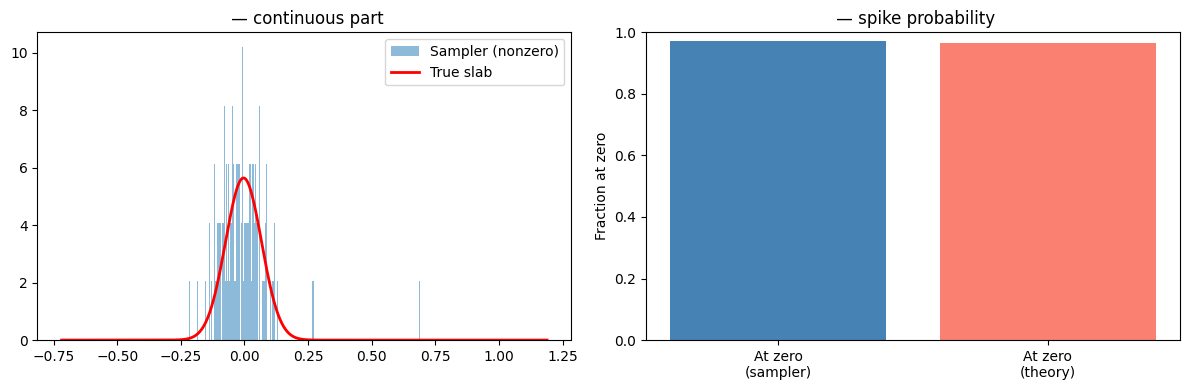

In [11]:
plot_spike_slab_marginal(x[:, 5], m[5], s2, gamma_post_j=gamma_post[5])